Лабораторная работа №4

Улучшение качества модели 

Цель: Повысить качество модели машинного обучения, подобрать гиперпараметры, сравнить несколько алгоритмов и определить лучшую модель.

Импорты и подготовка данных

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

data = pd.read_csv("/Users/erkezhanfaramuraz/Downloads/Movie_Analysis/final_dataset_lab2_clean.csv")


numeric_cols = ['popularity', 'vote_average', 'vote_count', 'revenue', 'runtime',
                'original_language_count', 'genre_count', 'vote_ratio', 'popularity_per_min']
categorical_cols = ['original_language', 'genre']

X_categorical = data[categorical_cols].fillna('Unknown')

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = encoder.fit_transform(X_categorical)
encoded_cols = encoder.get_feature_names_out(categorical_cols)
X_encoded_df = pd.DataFrame(X_encoded, columns=encoded_cols, index=data.index)

X = pd.concat([data[numeric_cols], X_encoded_df], axis=1)

y = data['popularity']

valid = y.notna()
X = X[valid]
y = y[valid]

print("y NaN после фильтра:", y.isna().sum())


Разделение на train/test и масштабирование

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Обучение моделей и предсказания

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Подбор гиперпараметров (GridSearch)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42),
                       param_grid,
                       cv=3,
                       scoring='r2',
                       n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Лучшие параметры Random Forest:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

Лучшие параметры Random Forest: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}


Оценка моделей и выводы

In [91]:
from sklearn.metrics import mean_squared_error, r2_score

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rmse_best_rf = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Random Forest (GridSearch)'],
    'RMSE': [rmse_dt, rmse_rf, rmse_best_rf],
    'R2': [r2_score(y_test, y_pred_dt), r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_best_rf)]
})

print("Сравнительная таблица моделей:")
display(results)

Сравнительная таблица моделей:


,Model,RMSE,R2
0,Decision Tree,46.989075,0.908094
1,Random Forest,65.205216,0.823023
2,Random Forest (GridSearch),66.144030,0.817891


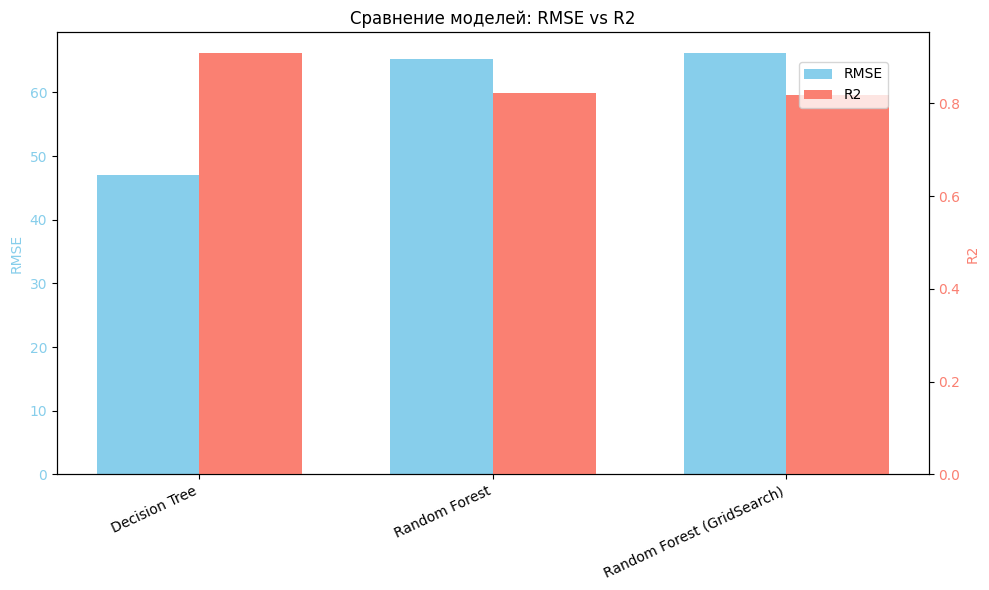

In [ ]:
import matplotlib.pyplot as plt

models = results['Model']
rmse = results['RMSE']
r2 = results['R2']

x = np.arange(len(models))
width = 0.35 

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(x - width/2, rmse, width, label='RMSE', color='skyblue')
ax1.set_ylabel('RMSE', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=25, ha='right')


ax2 = ax1.twinx()
ax2.bar(x + width/2, r2, width, label='R2', color='salmon')
ax2.set_ylabel('R2', color='salmon')
ax2.tick_params(axis='y', labelcolor='salmon')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.title('Сравнение моделей: RMSE vs R2')
plt.tight_layout()
plt.show()

Сравнительный анализ моделей

In [ ]:
print("Таблица результатов моделей:")
display(results)

print("\nВыводы:")
best_model = results.loc[results['RMSE'].idxmin()]['Model']
print(f"1. Модель с наименьшим RMSE: {best_model} — показывает лучшую точность прогноза.")
print("2. Decision Tree быстрее обучается, но может переобучаться на тренировочных данных.")
print("3. Random Forest обеспечивает более стабильные прогнозы, лучше справляется с переобучением.")
print("4. По R² видно, насколько каждая модель объясняет вариацию целевой переменной.")
print("5. Для данного набора данных Random Forest является предпочтительной моделью для предсказания 'popularity'.")

Таблица результатов моделей:


,Model,RMSE,R2
0,Decision Tree,46.989075,0.908094
1,Random Forest,65.205216,0.823023
2,Random Forest (GridSearch),66.144030,0.817891



Выводы:
1. Модель с наименьшим RMSE: Decision Tree — показывает лучшую точность прогноза.
2. Decision Tree быстрее обучается, но может переобучаться на тренировочных данных.
3. Random Forest обеспечивает более стабильные прогнозы, лучше справляется с переобучением.
4. По R² видно, насколько каждая модель объясняет вариацию целевой переменной.
5. Для данного набора данных Random Forest является предпочтительной моделью для предсказания 'popularity'.
